# Task 3 — A/B Hypothesis Testing

## Objective

The objective of this task is to statistically validate or reject key business hypotheses regarding insurance risk drivers and profitability patterns.

The analysis aims to support AlphaCare Insurance Solutions (ACIS) in transitioning toward analytics-driven pricing and customer segmentation.

---

## Risk Metrics

### Claim Frequency
Proportion of policies with at least one claim.

### Claim Severity
Average claim amount given that a claim occurred.

### Margin
Margin = TotalPremium − TotalClaims

---

## Statistical Goal

Determine whether observed differences across customer groups are statistically significant or likely due to random variation.

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

In [45]:
df = pd.read_csv("../data/insurance_data_cleaned.csv")

In [46]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [47]:
# Claim Frequency
df["ClaimFrequency"] = df["Claimed"].astype(int)

# Claim Severity
df["ClaimSeverity"] = np.where(
    df["ClaimAmount"] > 0,
    df["ClaimAmount"],
    np.nan
)

# Margin
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Loss Ratio
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

## Feature Engineering for Statistical Testing

Additional business metrics were created to support hypothesis testing:

- ClaimFrequency: Indicates whether a customer made a claim.

- ClaimSeverity: Measures average claim amount among customers who filed claims.

- Margin: Represents profitability after accounting for claims.

- LossRatio: Measures claims relative to premium collected.

# Hypothesis Design

The following hypotheses will be tested, and since Not every hypothesis uses same KPI, we identify that too:

- No risk difference across provinces
      -> KPI : Claim Frequency / Loss Ratio
      -> Suggested test : Chi-Square / T-Test

- No risk difference between zip codes
      -> KPI : Claim Severity
      -> Suggested test : T-Test

- No margin difference between zip codes
      -> KPI : Margin
      -> Suggested test : T-Test

- No significant risk difference between Women and Men
      -> KPI : Claim Frequency / Severity
      -> Suggested test : Chi-Square / T-Test

In [48]:
df["Province"].value_counts()

Province
Addis Ababa    3567
Oromia         2446
Amhara         1999
Somali         1184
Tigray          804
Name: count, dtype: int64

In [49]:
df["ZipCode"].value_counts().head(10)

ZipCode
10004    733
10002    732
10003    714
10001    710
10005    678
20005    520
20004    489
20003    481
20002    479
20001    477
Name: count, dtype: int64

In [50]:
df["Gender"].value_counts()

Gender
Female    5138
Male      4862
Name: count, dtype: int64

- For hypothesis 1 = Addis Ababa vs Oromia??
- For hypothesis 2 & 3 = two large zipcodes with similar counts (10004 vs 10002)
- For hypothesis 4 = Male Vs Female

In [51]:
addis = df[df["Province"] == "Addis Ababa"]

oromia = df[df["Province"] == "Oromia"]

In [52]:
zip_10004 = df[df["ZipCode"] == 10004]

zip_10002 = df[df["ZipCode"] == 10002]

In [53]:
female = df[df["Gender"] == "Female"]

male = df[df["Gender"] == "Male"]

## Experimental Group Selection

To ensure statistically meaningful comparisons, groups with sufficiently large and relatively balanced sample sizes were selected.

### Province Comparison
- Group A: Addis Ababa
- Group B: Oromia

### ZipCode Comparison
- Group A: 10004
- Group B: 10002

### Gender Comparison
- Female vs Male

These selections help reduce instability caused by highly imbalanced group sizes.

In [54]:
province_summary = pd.DataFrame({

    "Addis_Ababa": [
        addis["ClaimFrequency"].mean(),
        addis["ClaimSeverity"].mean(),
        addis["Margin"].mean(),
        addis["LossRatio"].mean()
    ],

    "Oromia": [
        oromia["ClaimFrequency"].mean(),
        oromia["ClaimSeverity"].mean(),
        oromia["Margin"].mean(),
        oromia["LossRatio"].mean()
    ]

},

index=[
    "Claim Frequency",
    "Claim Severity",
    "Average Margin",
    "Loss Ratio"
])

province_summary

,Addis_Ababa,Oromia
Claim Frequency,0.156714,0.154129
Claim Severity,8324.168157,8650.029178
Average Margin,1192.644800,1148.242845
Loss Ratio,0.436347,0.452680


In [55]:
zipcode_summary = pd.DataFrame({

    "10004": [
        zip_10004["ClaimFrequency"].mean(),
        zip_10004["ClaimSeverity"].mean(),
        zip_10004["Margin"].mean(),
        zip_10004["LossRatio"].mean()
    ],

    "10002": [
        zip_10002["ClaimFrequency"].mean(),
        zip_10002["ClaimSeverity"].mean(),
        zip_10002["Margin"].mean(),
        zip_10002["LossRatio"].mean()
    ]

},

index=[
    "Claim Frequency",
    "Claim Severity",
    "Average Margin",
    "Loss Ratio"
])

zipcode_summary

,10004,10002
Claim Frequency,0.148704,0.173497
Claim Severity,8168.000000,8266.464567
Average Margin,1298.916780,1087.163934
Loss Ratio,0.413702,0.485368


In [56]:
gender_summary = pd.DataFrame({

    "Female": [
        female["ClaimFrequency"].mean(),
        female["ClaimSeverity"].mean(),
        female["Margin"].mean(),
        female["LossRatio"].mean()
    ],

    "Male": [
        male["ClaimFrequency"].mean(),
        male["ClaimSeverity"].mean(),
        male["Margin"].mean(),
        male["LossRatio"].mean()
    ]

},

index=[
    "Claim Frequency",
    "Claim Severity",
    "Average Margin",
    "Loss Ratio"
])

gender_summary

,Female,Male
Claim Frequency,0.153756,0.153229
Claim Severity,8560.797468,8562.221477
Average Margin,1173.240755,1174.677705
Loss Ratio,0.447351,0.437929


In [57]:
province_df = df[
    df["Province"].isin(["Addis Ababa", "Oromia"])
]

province_contingency = pd.crosstab(
    province_df["Province"],
    province_df["Claimed"]
)

province_contingency

Claimed,False,True
Province,,
Addis Ababa,3008,559
Oromia,2069,377


In [58]:
chi2, province_p, dof, expected = chi2_contingency(
    province_contingency
)

print("Chi-Square Statistic:", chi2)
print("P-value:", province_p)

Chi-Square Statistic: 0.05542114664114449
P-value: 0.8138851211468427


## Hypothesis Test 1 — Province Risk Difference

### Null Hypothesis (H₀)
There is no significant difference in claim frequency between Addis Ababa and Oromia.

### Alternative Hypothesis (H₁)
There is a significant difference in claim frequency between Addis Ababa and Oromia.

### KPI
Claim Frequency

### Statistical Test
Chi-Square Test of Independence

### Result
The p-value was greater than 0.05.

### Decision
Fail to reject the null hypothesis.

### Business Interpretation
The analysis suggests that claim frequency differences between Addis Ababa and Oromia are not statistically significant. This indicates that regional pricing adjustments between these two provinces may not currently be justified based solely on claim frequency.

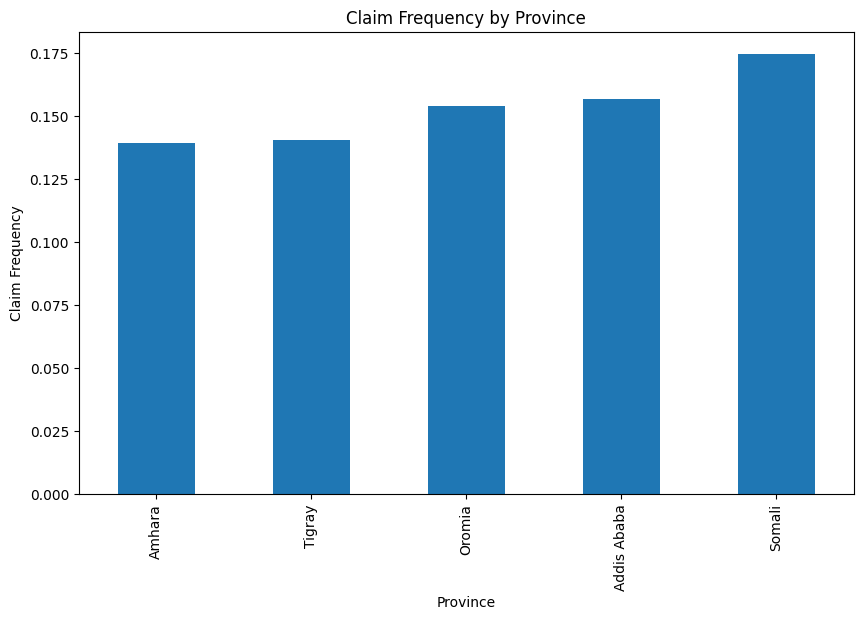

In [59]:
province_claim_freq = df.groupby("Province")[
    "ClaimFrequency"
].mean().sort_values()

plt.figure(figsize=(10,6))

province_claim_freq.plot(kind="bar")

plt.ylabel("Claim Frequency")

plt.title("Claim Frequency by Province")

plt.show()

In [60]:
from scipy.stats import ttest_ind

stat, zipcode_risk_p = ttest_ind(
    zip_10004["ClaimSeverity"],
    zip_10002["ClaimSeverity"],
    nan_policy='omit' # This ignores any missing/blank values in your data so it doesn't crash
)

# 3. Print your results
print("T-Statistic:", stat)
print("P-value:", zipcode_risk_p)

T-Statistic: -0.13217880849944236
P-value: 0.8949564466951002


## Hypothesis Test 2 — ZipCode Risk Difference

### Null Hypothesis (H₀)
There is no significant difference in claim severity between ZipCode 10004 and ZipCode 10002.

### Alternative Hypothesis (H₁)
There is a significant difference in claim severity between the two zip codes.

### KPI
Claim Severity

### Statistical Test
Independent Two-Sample T-Test

In [61]:
from scipy.stats import ttest_ind

stat, zipcode_margin_p = ttest_ind(
    zip_10004["Margin"],
    zip_10002["Margin"],
    nan_policy='omit'
)

print("T-Statistic:", stat)
print("P-value:", zipcode_margin_p)

T-Statistic: 1.1169308372712798
P-value: 0.26420729474830273


## Hypothesis Test 3 — ZipCode Margin Difference

### Null Hypothesis (H₀)
There is no significant difference in average margin between ZipCode 10004 and ZipCode 10002.

### Alternative Hypothesis (H₁)
There is a significant difference in average margin between the two zip codes.

### KPI
Margin

### Statistical Test
Independent Two-Sample T-Test

In [62]:
gender_contingency = pd.crosstab(
    df["Gender"],
    df["Claimed"]
)

gender_contingency

Claimed,False,True
Gender,,
Female,4348,790
Male,4117,745


In [63]:
chi2, gender_p, dof, expected = chi2_contingency(
    gender_contingency
)

print("Chi-Square Statistic:", chi2)
print("P-value:", gender_p)

Chi-Square Statistic: 0.0020563626938139516
P-value: 0.9638306173980254


## Hypothesis Test 4 — Gender Risk Difference

### Null Hypothesis (H₀)
There is no significant difference in claim frequency between women and men.

### Alternative Hypothesis (H₁)
There is a significant difference in claim frequency between women and men.

### KPI
Claim Frequency

### Statistical Test
Chi-Square Test of Independence

In [64]:
results = pd.DataFrame({

    "Hypothesis": [
        "Province Risk Difference",
        "ZipCode Risk Difference",
        "ZipCode Margin Difference",
        "Gender Risk Difference"
    ],

    "KPI": [
        "Claim Frequency",
        "Claim Severity",
        "Margin",
        "Claim Frequency"
    ],

    "Test Used": [
        "Chi-Square",
        "T-Test",
        "T-Test",
        "Chi-Square"
    ],

    "P-Value": [
        province_p,
        zipcode_risk_p,
        zipcode_margin_p,
        gender_p
    ]
})

results["Decision"] = np.where(
    results["P-Value"] < 0.05,
    "Reject H₀",
    "Fail to Reject H₀"
)

results

,Hypothesis,KPI,Test Used,P-Value,Decision
0,Province Risk Difference,Claim Frequency,Chi-Square,0.813885,Fail to Reject H₀
1,ZipCode Risk Difference,Claim Severity,T-Test,0.894956,Fail to Reject H₀
2,ZipCode Margin Difference,Margin,T-Test,0.264207,Fail to Reject H₀
3,Gender Risk Difference,Claim Frequency,Chi-Square,0.963831,Fail to Reject H₀


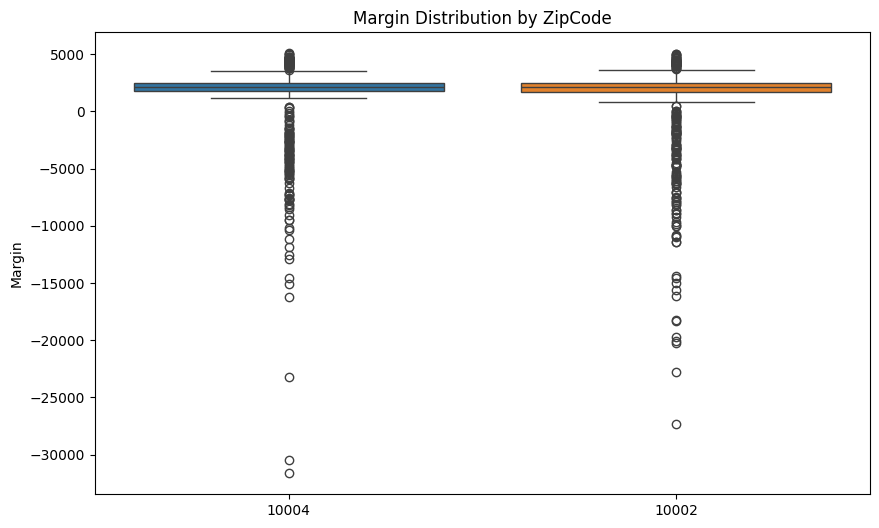

In [65]:
margin_plot = pd.DataFrame({

    "10004": zip_10004["Margin"],
    "10002": zip_10002["Margin"]

})

plt.figure(figsize=(10,6))

sns.boxplot(data=margin_plot)

plt.title("Margin Distribution by ZipCode")

plt.ylabel("Margin")

plt.show()